In [2]:
import pandas as pd
import numpy as np
from plotly.subplots import make_subplots
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df_films = pd.read_csv('../data/limpos/pixar_films.csv')
df_rating = pd.read_csv('../data/limpos/public_response.csv')
df_box = pd.read_csv('../data/limpos/box_office.csv')
df_genre = pd.read_csv('../data/limpos/genres.csv')
df_academy = pd.read_csv('../data/limpos/academy.csv')
df = pd.read_csv('../data/limpos/df.csv')

In [4]:
fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(go.Scatter(x=df["release_date"], y=df["imdb_score"], mode="lines+markers", name="Avaliação IMDb"), secondary_y=False)

fig.add_trace(go.Scatter(x=df["release_date"], y=df["box_office_worldwide"], mode="lines+markers", name="Bilheteria Mundial"), secondary_y=True)

fig.update_layout(template="plotly_dark")

fig.update_yaxes(title_text="Avaliação IMDb", secondary_y=False)

fig.update_yaxes(title_text="Bilheteria mundial", secondary_y=True)

fig.show()

In [5]:
df_genre = pd.merge(df_rating, df_genre,on='film', how='left')
df_genre = pd.merge(df_box, df_genre,on='film', how='left')
df_genre2 = df_genre
df_genre = df_genre.groupby('value', as_index=False)['imdb_score'].mean()
df_genre = df_genre.sort_values(by='imdb_score', ascending=True)
print(df_genre)


                      value  imdb_score
37              Time Travel    6.100000
11                    Crime    6.200000
30                      Spy    6.200000
7                Car Action    6.450000
20               Motorsport    6.700000
29                    Sport    6.700000
12       Dinosaur Adventure    6.700000
25                  Romance    7.000000
0                    Action    7.080000
34           Teen Adventure    7.100000
31                Superhero    7.200000
15               Fairy Tale    7.250000
28             Space Sci-Fi    7.250000
33          Sword & Sorcery    7.250000
35              Teen Comedy    7.300000
26                   Sci-Fi    7.333333
18             Fantasy Epic    7.400000
3          Animal Adventure    7.480000
4                 Animation    7.542857
1                 Adventure    7.542857
10       Computer Animation    7.542857
23                    Quest    7.566667
8                    Comedy    7.571429
9             Coming-of-Age    7.583333


In [6]:
fig2 = px.bar(df_genre, x='value', y='imdb_score', template='plotly_dark', labels={'value': 'Gênero', 'imdb_score': 'Avaliação IMDb'}, color_continuous_scale='Blues', color='imdb_score', title='Rating por gênero')
fig2.show()

In [7]:
def score(status):
    if status == 'Won':
        return 2
    if status == 'Nominated':
        return 1
    return 0

df_academy['score'] = df_academy['status'].apply(score)

df_agrup = df_academy.groupby('film', as_index=False)['score'].sum()

df_agrup = pd.merge(df_agrup, df, how='left')

df_agrup = df_agrup.groupby('franchise', as_index=False)['score'].sum()
        
df_agrup = df_agrup.sort_values(by='score', ascending=False)

In [8]:
fig3 = px.bar(df_agrup, x='score', y='franchise', template='plotly_dark', color='franchise', title='Prêmios ou indicações por franquia', labels={'franchise': 'Franquia',
                                                                                                                                                 'score': 'Indicações'})
fig3.show()

In [9]:
fig4 = px.scatter(df, x='imdb_score', y='box_office_worldwide', color='film', template='plotly_dark', title='Bilheteria x Score', labels={'box_office_worldwide': 'Bilheteria Mundial',
                                                                                                                                          'imdb_score': 'Avaliação IMDB', 'film': 'Filme'})
fig4.show()

In [10]:
df_agrup = df.groupby('film', as_index=False)[['box_office_worldwide', 'budget']].sum()

df_agrup['profit'] = df_agrup['box_office_worldwide'] - df_agrup['budget']
df_agrup['profit'] = df_agrup['profit'].astype(int)
df_agrup = df_agrup.sort_values(by='profit', ascending=False)

fig5 = px.histogram(df_agrup, x='film', y='profit', color='film', template='plotly_dark', labels={'profit': 'Lucro',
                                                                                                  'film': 'Filme'}, title='Lucro por filme')
fig5.show()

In [11]:
df_agrup = df_genre2.groupby('value', as_index=False)[['box_office_worldwide', 'imdb_score']].mean()
df_agrup['box_office_worldwide'] = df_agrup['box_office_worldwide'].astype(int)
df_agrup


,value,box_office_worldwide,imdb_score
0,Action,594372749,7.080000
1,Adventure,608664319,7.542857
2,Adventure Epic,521311860,8.400000
3,Animal Adventure,643755696,7.480000
4,Animation,608664319,7.542857
5,Artificial Intelligence,521311860,8.400000
6,Buddy Comedy,531608121,7.825000
7,Car Action,471891526,6.450000
8,Comedy,606418293,7.571429
9,Coming-of-Age,650441683,7.583333


In [12]:
fig = px.scatter(
    df,
    x='budget',
    y='box_office_worldwide',
    size='imdb_score',
    hover_name='film',
    template='plotly_dark',
    labels={
        'budget': 'Orçamento',
        'box_office_worldwide': 'Bilheteria Mundial',
        'imdb_score': 'Nota IMDb',
        'main_genre': 'Gênero'
    },
    title='Orçamento x Bilheteria dos Filmes da Pixar'
)

fig.show()

In [13]:
df

,number,film,release_date,imdb_score,budget,box_office_worldwide,franchise
0,1,Toy Story,1995-11-22,8.3,30000000.0,394436586,NaN
1,2,A Bug's Life,1998-11-25,7.2,120000000.0,363258859,NaN
2,3,Toy Story 2,1999-11-24,7.9,90000000.0,511358276,Toy Story
3,4,"Monsters, Inc.",2001-11-02,8.1,115000000.0,528773250,"Monsters, Inc. & University"
4,5,Finding Nemo,2003-05-30,8.2,94000000.0,871014978,Finding Nemo/Dory
5,6,The Incredibles,2004-11-05,8.0,92000000.0,631442092,The Incredibles
6,7,Cars,2006-06-09,7.2,120000000.0,461983149,Cars
7,8,Ratatouille,2007-06-29,8.1,150000000.0,623726085,NaN
8,9,WALL-E,2008-06-27,8.4,180000000.0,521311860,NaN
9,10,Up,2009-05-29,8.3,175000000.0,735099082,NaN


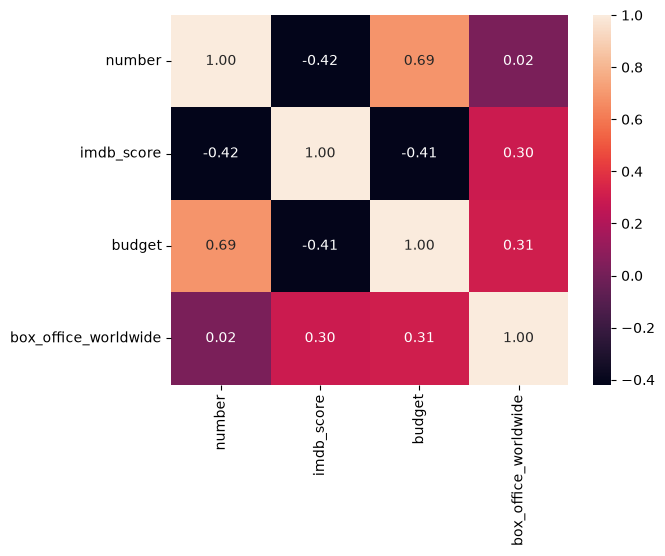

In [14]:
df_heat = df.drop(
    columns=['release_date', 'film', 'franchise']
)

correlation = df_heat.corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f'
)

plt.show()

In [15]:
df_sunburst = df.copy()

df_sunburst['franchise'] = df_sunburst['franchise'].fillna('Standalone')

fig = px.sunburst(
    df_sunburst,
    path=['franchise', 'film'],
    values='box_office_worldwide',
    color='imdb_score',
    color_continuous_scale='Blues',
    template='plotly_dark',
    title='Bilheteria dos Filmes por Franquia'
)

fig.show()

In [16]:
df_donut = df_sunburst[
    df_sunburst['franchise'] != 'Standalone'
]

df_donut = (
    df_donut
    .groupby('franchise', as_index=False)['box_office_worldwide']
    .sum()
)

fig = px.pie(
    df_donut,
    names='franchise',
    values='box_office_worldwide',
    hole=0.5,
    template='plotly_dark',
    title='Participação das Franquias na Bilheteria Mundial'
)

fig.update_traces(
    textinfo='percent+label'
)

fig.show()

In [21]:
df2 = pd.merge(df, df_rating, on='film', how='left')

fig = px.histogram(
    df2,
    x='rotten_tomatoes_score',
    template='plotly_dark',
    title='Distribuição das Notas Rotten Tomatoes'
)

fig.update_traces(
    xbins=dict(
        start=40,
        end=100,
        size=10
    )
)

fig.update_layout(
    xaxis=dict(
        title='Nota Rotten Tomatoes',
        tick0=40,
        dtick=10,
        range=[40, 100]
    ),
    yaxis_title='Quantidade de Filmes',
    bargap=0.05
)

fig.show()